# Fitting MOSK GPs using Stan

This notebook demonstrates using Stan in python for fitting MOSK GPs.

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import nutpie
import arviz as az

os.environ["TBB_CXX_TYPE"] = "clang"  # or 'gcc'

az.style.use("arviz-vibrant")

In [34]:
#filename_stub = "D2-Q1-seed2727-n100-mcar0.2-sigma0.1"
filename_stub = "D2-Q1-seed6893-n200-mnar0.3-sigma0.1"

D = 2
Q = 1

input_df = pd.read_csv(f'data/{filename_stub}-sim.csv')
input_df.head()

,t,f,y,y_se,d
0,0.060606,-2.439000,-2.423720,0.1,1
1,0.070707,-2.202585,-2.159215,0.1,1
2,0.080808,-1.653379,-1.572157,0.1,1
3,0.090909,-0.868532,-0.996510,0.1,1
4,0.101010,0.040578,0.004967,0.1,1


In [35]:
input_df.describe()

,t,f,y,y_se,d
count,139.000000,139.000000,139.000000,1.390000e+02,139.000000
mean,0.482160,-0.004613,0.002541,1.000000e-01,1.532374
std,0.293047,1.492364,1.502861,2.507036e-16,0.500755
min,0.000000,-2.440734,-2.576006,1.000000e-01,1.000000
25%,0.232323,-1.373205,-1.324769,1.000000e-01,1.000000
50%,0.464646,0.006374,0.023879,1.000000e-01,2.000000
75%,0.732323,1.267754,1.295517,1.000000e-01,2.000000
max,1.000000,2.459846,2.669196,1.000000e-01,2.000000


In [36]:
sorted(input_df['d'].unique())

[np.int64(1), np.int64(2)]

In [37]:
input_params = pd.read_table(f'data/{filename_stub}-param.tsv')
input_params

,seed,w,Sigma,mu,theta,phi
0,6893,0.96,0.25,5.98,-0.58,0.17
1,6893,1.50,0.69,4.79,0.18,2.01


In [38]:
ns = input_df['d'].value_counts().to_numpy()
ns

array([74, 65])

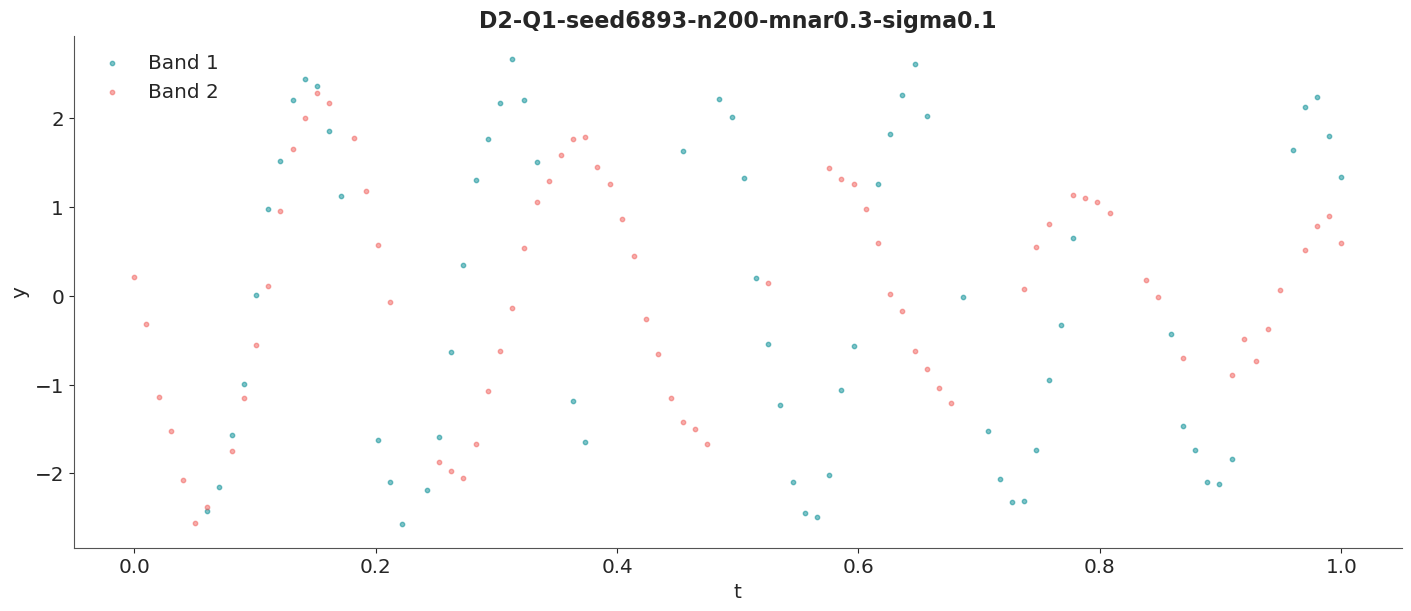

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
legends = []

for band in sorted(input_df['d'].unique()):
    cond = input_df["d"] == band
    xs = input_df.loc[cond, "t"]
    ys = input_df.loc[cond, "y"]
    ax.scatter(xs, ys, s=10, alpha=0.5, marker="o")   
    legends.append(f"Band {band}")

plt.title(f"{filename_stub}")
plt.xlabel("t")
plt.ylabel("y")
plt.legend(legends, loc="upper left");

In [40]:
data = {
    "N": input_df.shape[0],
    "ns": ns,
    "d": input_df['d'],
    "x": input_df['t'],
    "y": input_df['y'],
    "y_se": input_df['y_se']
}

In [41]:
compiled_model = nutpie.compile_stan_model(filename='stan/moskgp-D2.stan').with_data(**data)

In [42]:
trace = nutpie.sample(
    compiled_model=compiled_model, 
    draws=1000,
    tune=1000,
    chains=6,
    cores=6, 
    progress_rate=2000
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,222,0.23,15
,2000,161,0.18,21
,2000,213,0.19,31
,2000,265,0.11,31
,2000,61,0.13,31
,2000,291,0.15,16


In [43]:
trace

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:      (chain: 6, draw: 1000, w_std_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2, phi_dim_0: 2, w_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│         * phi_dim_0    (phi_dim_0) int64 16B 0 1
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│       Data variables:
│           w_std        (chain, draw, w_std_dim_0) float64 96kB 0.5265 ... 0.2967
│           Sigma        (chain, draw, Sigma_dim_0) float64 96kB 6.838 1.523 ... 1.385
│           mu           (chain, draw, mu_dim_0) float64 96kB 5.522 4.866 ... 5.022
│           theta        (chain, draw, theta_dim_0) float64 96kB -4.034 0.8556 ... -2.56
│           phi          (chain, draw, phi_dim_0) float64 96kB -1.213 2.296 ... 0.7041
│           deltaTheta   (chain, draw) float64 48kB 4.89 5.852 6.729 ... 3.027 3.283
│           w            (chain, draw, w_dim_0) float64 96kB 0.7912 0.716 ... 0.4459
│       Attributes:
│           created_at:                 2026-09-19T10:43:31.450793+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Dimensions:                   (chain: 6, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 48B 0 1 2 3 4 5
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 48kB 4 4 4 5 4 ... 4 5 3 4 4
│           maxdepth_reached          (chain, draw) bool 6kB False False ... False False
│           step_size                 (chain, draw) float64 48kB 0.2268 ... 0.1538
│           transformation_update_id  (chain, draw) int64 48kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 48kB 0.2098 ... 0.1651
│           mean_tree_accept          (chain, draw) float64 48kB 0.9764 ... 0.5553
│           ...                        ...
│           fisher_distance           (chain, draw) float64 48kB 8.0 7.616 ... 20.48
│           transformation_index      (chain, draw) int64 48kB 847 847 847 ... 847 847
│           diverging                 (chain, draw) bool 6kB False False ... True True
│           divergence_draw           (chain, draw) uint64 48kB 0 0 0 ... 1998 1999 2000
│           divergence_message        (chain, draw) object 48kB nan ... "Error during...
│           divergence_energy_error   (chain, draw) float64 48kB nan nan ... nan
│       Attributes:
│           created_at:                  2026-09-19T10:43:31.466554+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /warmup_posterior
│       Dimensions:      (chain: 6, draw: 1000, w_std_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2, phi_dim_0: 2, w_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) i

In [44]:
trace.sample_stats.diverging.sum()

<xarray.DataArray 'diverging' ()> Size: 8B
array(1213)

In [45]:
az.ess(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_std_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2, w_dim_0: 2)
    Coordinates:
      * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
      * w_dim_0      (w_dim_0) int64 16B 0 1
    Data variables:
        w_std        (w_std_dim_0) float64 16B 13.21 85.6
        Sigma        (Sigma_dim_0) float64 16B 13.25 13.33
        mu           (mu_dim_0) float64 16B 13.19 13.15
        theta        (theta_dim_0) float64 16B 37.57 33.26
        phi          (phi_dim_0) float64 16B 128.1 94.46
        deltaTheta   float64 8B 13.12
        w            (w_dim_0) float64 16B 13.21 85.6

In [22]:
az.rhat(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_std_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2, w_dim_0: 2)
    Coordinates:
      * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
      * w_dim_0      (w_dim_0) int64 16B 0 1
    Data variables:
        w_std        (w_std_dim_0) float64 16B 1.019 1.014
        Sigma        (Sigma_dim_0) float64 16B 1.019 1.005
        mu           (mu_dim_0) float64 16B 1.02 1.011
        theta        (theta_dim_0) float64 16B 1.008 1.021
        phi          (phi_dim_0) float64 16B 1.005 1.003
        deltaTheta   float64 8B 1.014
        w            (w_dim_0) float64 16B 1.019 1.014

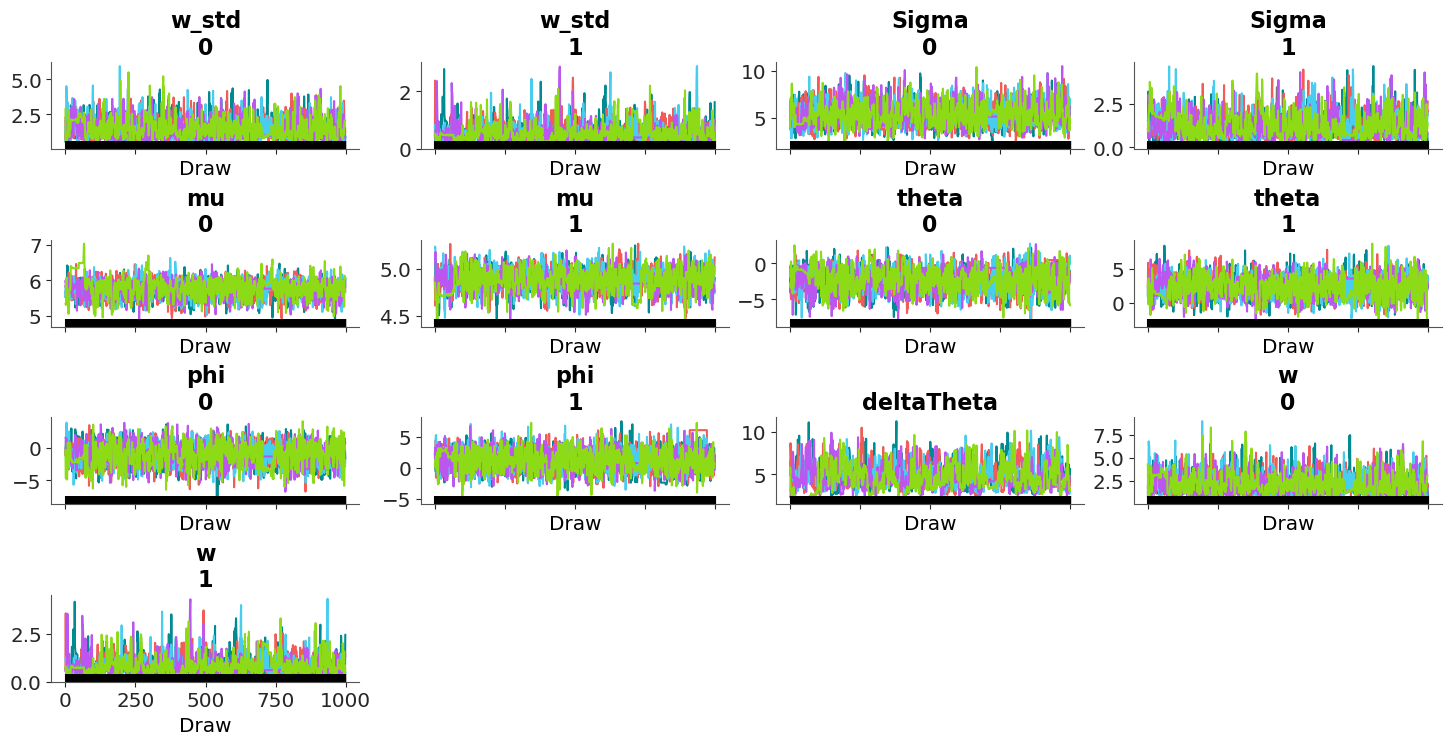

In [52]:
selected_chains = [0,1,2,3,5]
az.plot_trace(trace.sel(chain = selected_chains));

In [53]:
az.diagnose(trace.sel(chain = selected_chains))

Divergences
1152 of 5000 (23.04%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
The following parameters have fewer than 500 effective samples:
  deltaTheta
This suggests that the sampler may not have fully explored the posterior distribution for this parameter.
Consider reparameterizing the model or increasing the number of samples.

R-hat
The following parameters have R-hat values greater than 1.01:
  theta, deltaTheta
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.


True

In [54]:
az.summary(trace.sel(chain = selected_chains))

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w_std[0],1.44,0.7,0.62,2.7,1635,1990,1.00,0.017,0.014
w_std[1],0.56,0.31,0.25,1.1,943,1083,1.00,0.01,0.012
Sigma[0],5.39,1.21,3.6,7.5,1538,1897,1.00,0.031,0.02
Sigma[1],1.16,0.69,0.37,2.4,625,366,1.01,0.026,0.016
mu[0],5.75,0.26,5.3,6.1,703,692,1.01,0.01,0.01
mu[1],4.879,0.115,4.7,5.1,1228,638,1.00,0.0033,0.0026
theta[0],-2.3,1.62,-4.9,0.38,585,590,1.01,0.067,0.028
theta[1],2.4,1.58,-0.11,4.9,1268,1494,1.00,0.045,0.026
phi[0],-1.15,1.66,-3.8,1.5,1395,1637,1.00,0.045,0.029
phi[1],1.2,1.7,-1.6,4,847,729,1.01,0.067,0.077


In [57]:
input_params

,seed,w,Sigma,mu,theta,phi
0,6893,0.96,0.25,5.98,-0.58,0.17
1,6893,1.50,0.69,4.79,0.18,2.01


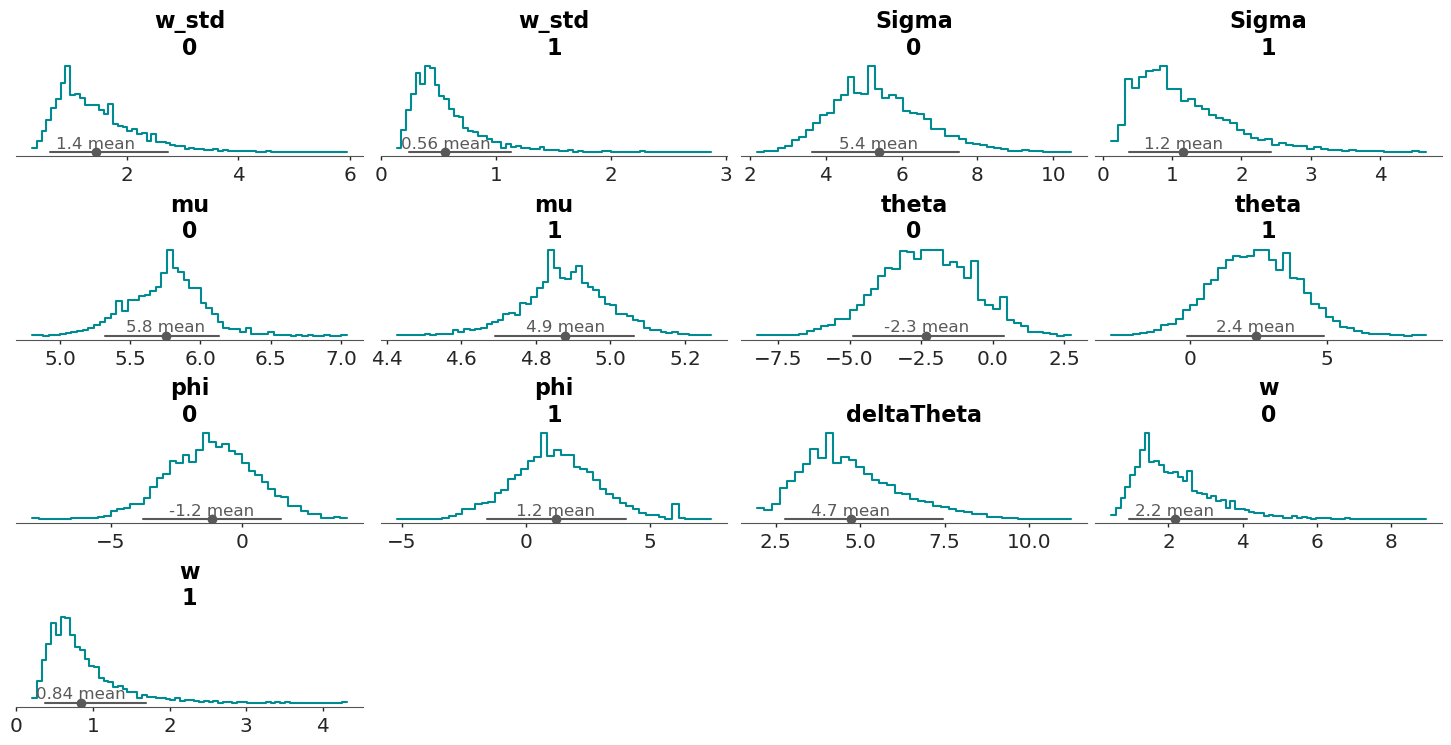

In [58]:
az.plot_dist(trace.sel(chain = selected_chains), kind="hist");

In [59]:
trace.sel(chain = selected_chains).to_netcdf(f'nc/{filename_stub}.nc')